In [ ]:
!rm -rf clone && git clone https://github.com/pui-sum-rv/lab5 clone && cp -a clone/. .

Cloning into 'clone'...
remote: Enumerating objects: 17, done.
remote: Counting objects: 100% (17/17), done.
remote: Compressing objects: 100% (13/13), done.
remote: Total 17 (delta 3), reused 11 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (17/17), 152.42 KiB | 5.64 MiB/s, done.
Resolving deltas: 100% (3/3), done.


In [ ]:
#zadatak 1.

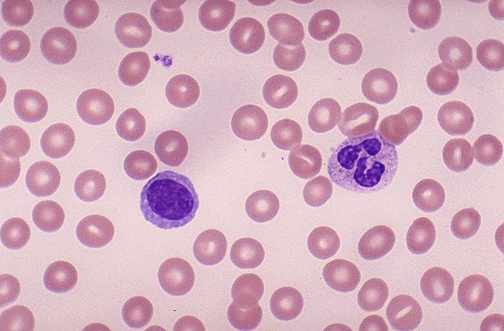

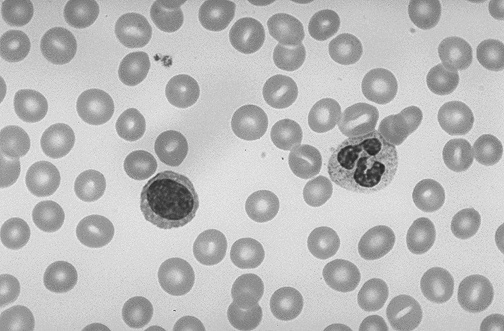

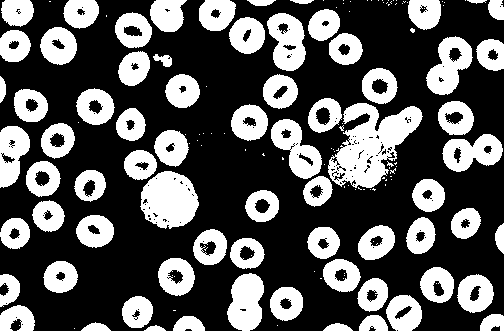

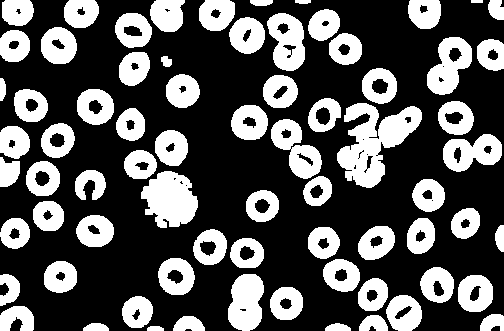

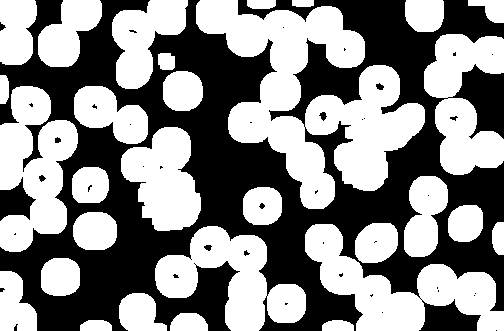

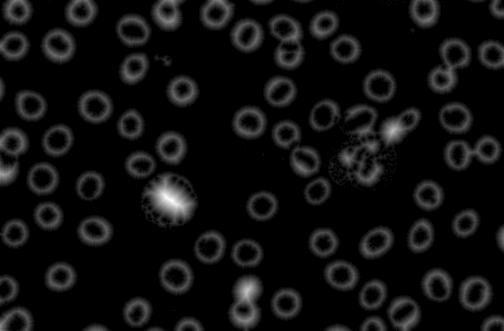

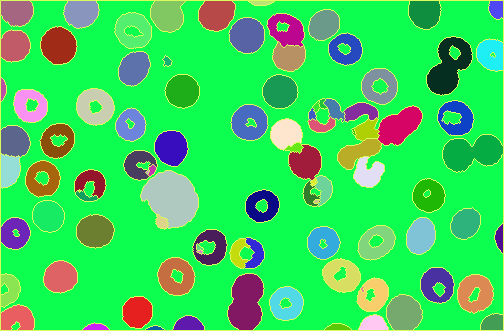

True

In [ ]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
import math
from google.colab.patches import cv2_imshow
import random as rng

# Load the source image
img = cv.imread('images/cells.jpg')
cv2_imshow(img)

# Convert image to grayscale
gray = cv.cvtColor(img,cv.COLOR_BGR2GRAY)
cv2_imshow(gray)

# Apply CLAHE (Ovaj dio otkomentiraš kada radiš usporedbu za zadaću)
clahe = cv.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
gray = clahe.apply(gray)

# OTSU threshold the image
# TODO:
thresh = cv.threshold(gray, 0, 255, cv.THRESH_BINARY_INV + cv.THRESH_OTSU)
cv.imwrite("images/thresholded.png", thresh[1])
cv2_imshow(thresh[1])

# Use morphological processing to remove noise from the image
# use 3x3 structuring element and opening operations
# TODO:
kernel = np.ones((3,3), np.uint8)

# TODO:
opening = cv.morphologyEx(thresh[1], cv.MORPH_OPEN, kernel, iterations=2)
cv2_imshow(opening)

# Finding sure background area
# TODO:
sure_bg = cv.dilate(opening, kernel, iterations=3)
cv2_imshow(sure_bg)

# Apply distance transform the image
dist_transform = cv.distanceTransform(thresh[1], cv.DIST_L2, 3)

# Normalize so that the distance transform image has minimum and maximum values from 0 to 1
cv.normalize(dist_transform, dist_transform, 0, 1.0, cv.NORM_MINMAX)
#cv.imwrite("images/distance_transform.png", dist_transform * 255)
cv2_imshow(dist_transform*255)

# Sure foreground area is where the distance transform has the highest values,
# so threshold the image so that every pixel below 0.2 is set to 0
ret, sure_fg = cv.threshold(dist_transform, 0.2*dist_transform.max(), 255, 0)

# Finding unknown region, i.e. the difference between sure foreground and sure background (the edges of the cells)
sure_fg = np.uint8(sure_fg)
unknown = cv.subtract(sure_bg,sure_fg)

# Find areas of connected pixels - we call these markers
ret, markers = cv.connectedComponents(sure_fg)

# Add one to all markers so that sure background is not 0, but 1
markers = markers+1

# Now, mark the region of unknown with zero
markers[unknown==255] = 0

# Finally, apply watershed to the image using the markers as guides
markers = cv.watershed(img, markers)

# Generate random colors
colors = []
for i in range(markers.shape[0] * markers.shape[1]):
    colors.append((rng.randint(0,256), rng.randint(0,256), rng.randint(0,256)))

# Create the result image
dst = np.zeros((markers.shape[0], markers.shape[1], 3), dtype=np.uint8)

# Fill labeled objects with random colors
for i in range(markers.shape[0]):
    for j in range(markers.shape[1]):
        index = markers[i,j]
        dst[i,j,:] = colors[index-1]

cv2_imshow(dst)
cv.imwrite("images/result_original.png", dst)

[[[ 93 251 218]
  [ 93 251 218]
  [ 93 251 218]
  ...
  [ 93 251 218]
  [ 93 251 218]
  [ 93 251 218]]

 [[ 93 251 218]
  [129 102 164]
  [129 102 164]
  ...
  [243  71  78]
  [243  71  78]
  [ 93 251 218]]

 [[ 93 251 218]
  [129 102 164]
  [129 102 164]
  ...
  [243  71  78]
  [243  71  78]
  [ 93 251 218]]

 ...

 [[ 93 251 218]
  [ 97  94 233]
  [ 97  94 233]
  ...
  [ 84 157  67]
  [ 84 157  67]
  [ 93 251 218]]

 [[ 93 251 218]
  [ 97  94 233]
  [ 97  94 233]
  ...
  [ 84 157  67]
  [ 84 157  67]
  [ 93 251 218]]

 [[ 93 251 218]
  [ 93 251 218]
  [ 93 251 218]
  ...
  [ 93 251 218]
  [ 93 251 218]
  [ 93 251 218]]]


In [ ]:
#zadatak 4 -

In [ ]:


'''
Na slici result_original.png gdje je CLAHE uključen algoritam je uspješno izolirao i segmentirao znatno veći broj pojedinačnih stanica.
Na slici result.png bez CLAHE-a primjećuje se ogroman broj spojenih stanica, a neke stanice na rubovima slike su potpuno nestale ili su krivo spojene s pozadinom.

Kada je CLAHE isključen Otsu pragovanje ne može kompenzirati te razlike u osvjetljenju i  kontrastu, pa binarizira sliku tako da se više susjednih stanica stopi u jednu veliku bijelu mrlju.
Zbog toga distanceTransform na tim mrljama ne može pronaći zasebne, izolirane vrhove pa se generira premalo markera za Watershed algoritam.
Uključivanjem CLAHE-a, kontrast se prilagođava lokalno u manjim regijama slike, što dramatično pojačava rubove stanica i ujednačava pozadinu.
To binariziranoj slici daje jasne granice, omogućujući distanceTransform-u da stvori precizne i odvojene vrhove za svaku stanicu što u konačnici rezultira točnijom i detaljnijom Watershed segmentacijom.
'''

'\nNa slici `result_original.png` (gdje je CLAHE uključen) algoritam je uspješno izolirao i segmentirao znatno veći broj pojedinačnih stanica.\nNa slici `result.png` (bez CLAHE-a) primjećuje se ogroman broj spojenih stanica (undersegmentation), a neke stanice na rubovima slike su potpuno nestale ili su krivo spojene s pozadinom.\n\nKada je CLAHE isključen, globalno Otsu pragovanje (thresholding) ne može kompenzirati te razlike, pa binarizira sliku tako da se više susjednih stanica stopi u jednu veliku bijelu mrlju.\nZbog toga `distanceTransform` na tim mrljama ne može pronaći zasebne, izolirane vrhove (lokalne maksimume), pa se generira premalo markera za Watershed algoritam. \nUključivanjem CLAHE-a, kontrast se prilagođava lokalno u manjim regijama (pločicama) slike, što dramatično pojačava rubove stanica i ujednačava pozadinu.\nTo binariziranoj slici daje jasne granice, omogućujući `distanceTransform`-u da stvori precizne i odvojene vrhove (izvore) za svaku stanicu, što u konačnici r